# Algorithm Walkthrough

Step-by-step inspection of the unfiltering pipeline:  
L1B filtered radiances → bin assignment → regression → unfiltered radiances → output NetCDF.

**Kernel:** Use the Poetry venv (`unfiltering` or `.venv`), not the conda `mr_env`.

In [1]:
import sys
sys.path.insert(0, '../../')

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

REPO = Path('../../')
L1B_FILE   = REPO / 'data/example_data/LIBERA_L1B_RAD-4CH_V0-5-5_20280212T033945_20280212T052007_R26154153835.nc'
M6_EXAMPLE = REPO / 'data/Modtran_6_data/FV3_Modtran6_IO_v5_write_v2_scene_1.nc'
COEF_FILE  = sorted((REPO / 'coefficients').glob('unfiltering_coefficients_*.nc'))[-1]
SRF_DIR    = REPO / 'data/SRF'

print('Coefficient file:', COEF_FILE.name)

Coefficient file: unfiltering_coefficients_v0.1.0_srf-0-0-1_modtran-3.7.nc


---
## 1. L1B Data

In [2]:
l1b = xr.open_dataset(L1B_FILE)
l1b

<xarray.Dataset> Size: 140MB
Dimensions:                                   (RADIOMETER_TIME: 602200,
                                               EUCLIDEAN_DIM: 3, N_HOURS: 24)
Coordinates:
    radiometer_time                           (RADIOMETER_TIME) datetime64[ns] 5MB ...
Dimensions without coordinates: RADIOMETER_TIME, EUCLIDEAN_DIM, N_HOURS
Data variables: (12/45)
    Latitude                                  (RADIOMETER_TIME) float32 2MB ...
    Terrain_Corrected_Latitude                (RADIOMETER_TIME) float32 2MB ...
    Colatitude                                (RADIOMETER_TIME) float32 2MB ...
    Longitude                                 (RADIOMETER_TIME) float32 2MB ...
    Terrain_Corrected_Longitude               (RADIOMETER_TIME) float32 2MB ...
    Altitude                                  (RADIOMETER_TIME) float32 2MB ...
    ...                                        ...
    Filtered_Radiance_LW_Uncertainty          (RADIOMETER_TIME) float32 2MB ...
    Filtered_Radiance_Tot                     (RADIOMETER_TIME) float32 2MB ...
    Filtered_Radiance_Tot_Uncertainty         (RADIOMETER_TIME) float32 2MB ...
    Filtered_Radiance_SSW                     (RADIOMETER_TIME) float32 2MB ...
    Filtered_Radiance_SSW_Uncertainty         (RADIOMETER_TIME) float32 2MB ...
    Quality_Flag                              (RADIOMETER_TIME) uint32 2MB ...
Attributes:
    ProductID:              RAD-4CH
    algorithm_version:      0.5.5
    Earth_Sun_Distance_AU:  0.9869897046363914
    Format:                 NetCDF-4
    Conventions:            CF-1.8
    ProjectLongName:        Libera
    ProjectShortName:       Libera
    PlatformLongName:       TBD
    PlatformShortName:      NOAA-22

In [3]:
# Filtered radiance units and value ranges
rad_vars = ['Filtered_Radiance_SW', 'Filtered_Radiance_SSW', 'Filtered_Radiance_LW', 'Filtered_Radiance_Tot']
rows = []
for v in rad_vars:
    da = l1b[v]
    rows.append({
        'variable': v,
        'units':    da.attrs.get('units', 'none'),
        'min':      float(da.min()),
        'max':      float(da.max()),
        'mean':     float(da.mean()),
        'std':      float(da.std()),
    })
pd.DataFrame(rows).set_index('variable')

,units,min,max,mean,std
variable,,,,,
Filtered_Radiance_SW,W/(m^2*sr*nm),3195.879639,3235.155273,3202.167969,0.097068
Filtered_Radiance_SSW,W/(m^2*sr*nm),36.365974,72.042290,36.594318,0.117445
Filtered_Radiance_LW,W/(m^2*sr*nm),3312.707275,3355.900635,3315.613770,0.112255
Filtered_Radiance_Tot,W/(m^2*sr*nm),1438.985352,1472.754150,1444.528809,1.423742


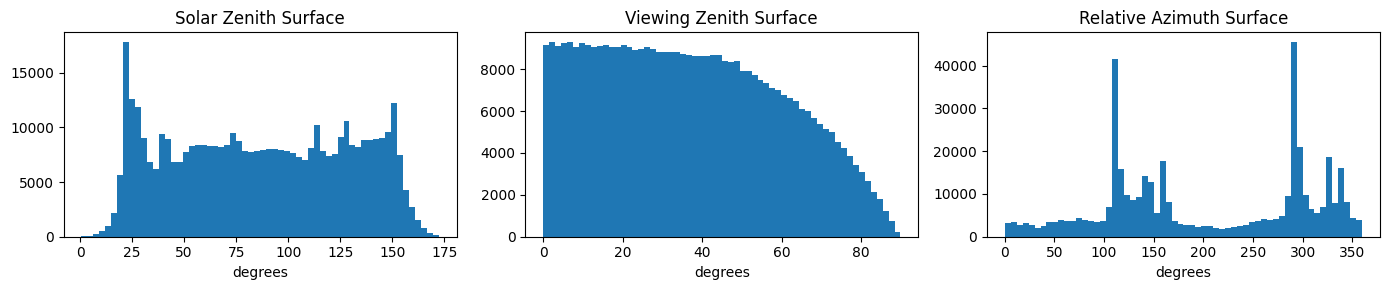

In [4]:
# Angle distributions
angle_vars = ['Solar_Zenith_Surface', 'Viewing_Zenith_Surface', 'Relative_Azimuth_Surface']
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, v in zip(axes, angle_vars):
    ax.hist(l1b[v].values, bins=60, edgecolor='none')
    ax.set_title(v.replace('_', ' '))
    ax.set_xlabel(l1b[v].attrs.get('units', 'deg'))
plt.tight_layout()

In [5]:
# Pull out the arrays we'll use throughout
sw_f  = l1b['Filtered_Radiance_SW'].values
ssw_f = l1b['Filtered_Radiance_SSW'].values
lw_f  = l1b['Filtered_Radiance_LW'].values
tot_f = l1b['Filtered_Radiance_Tot'].values
sza   = l1b['Solar_Zenith_Surface'].values
vza   = l1b['Viewing_Zenith_Surface'].values
raz   = l1b['Relative_Azimuth_Surface'].values
lat   = l1b['Latitude'].values
lon   = l1b['Longitude'].values
qf    = l1b['Quality_Flag'].values
times = l1b['radiometer_time'].values

print(f'N samples: {len(times):,}')
print(f'Time range: {times[0]} → {times[-1]}')

N samples: 602,200
Time range: 2028-02-12T03:39:45.340384000 → 2028-02-12T05:20:07.435110000


---
## 2. Unit Comparison: L1B vs MODTRAN 6

Both files claim similar-sounding units, but the area denominator differs:
- L1B: `W/(m²·sr·nm)`  
- MODTRAN6 spectral: `W SR-1 CM-2 / NM` = `W/(cm²·sr·nm)`

Since 1 m² = 10⁴ cm², the M6 values must be multiplied by **10⁴** to match the L1B scale.

In [6]:
m6 = xr.open_dataset(M6_EXAMPLE)

# Pre-integrated (SRF-filtered) radiances already in the M6 file
m6_sw_rad  = m6['MODTRAN6_SW_RAD_TOA_CERES_TRMM'].values   # W SR-1 CM-2,  shape (vza, raa, sza)
m6_lw_rad  = m6['MODTRAN6_LW_RAD_TOA_CERES_TRMM'].values
m6_tot_rad = m6['MODTRAN6_TOT_RAD_TOA_CERES_TRMM'].values

print('MODTRAN6 pre-integrated radiances (W SR-1 CM-2):')
print(f'  SW  range: [{m6_sw_rad.min():.4e}, {m6_sw_rad.max():.4e}]')
print(f'  LW  range: [{m6_lw_rad.min():.4e}, {m6_lw_rad.max():.4e}]')
print(f'  TOT range: [{m6_tot_rad.min():.4e}, {m6_tot_rad.max():.4e}]')

print()
print('After × 1e4 conversion to W/(m²·sr):')
print(f'  SW  range: [{m6_sw_rad.min()*1e4:.1f}, {m6_sw_rad.max()*1e4:.1f}]')
print(f'  LW  range: [{m6_lw_rad.min()*1e4:.1f}, {m6_lw_rad.max()*1e4:.1f}]')

print()
print('L1B filtered radiances (W/(m²·sr·nm) — may be mislabeled, likely W/(m²·sr)):')
print(f'  SW  range: [{sw_f.min():.1f}, {sw_f.max():.1f}]')
print(f'  LW  range: [{lw_f.min():.1f}, {lw_f.max():.1f}]')

MODTRAN6 pre-integrated radiances (W SR-1 CM-2):
  SW  range: [6.0835e-04, 2.4434e-02]
  LW  range: [6.6960e-03, 8.9365e-03]
  TOT range: [8.5030e-03, 3.1167e-02]

After × 1e4 conversion to W/(m²·sr):
  SW  range: [6.1, 244.3]
  LW  range: [67.0, 89.4]

L1B filtered radiances (W/(m²·sr·nm) — may be mislabeled, likely W/(m²·sr)):
  SW  range: [3195.9, 3235.2]
  LW  range: [3312.7, 3355.9]


In [7]:
# Spectral radiance from M6 vs what our Modtran6NC integrator produces
from tp7.modtran6 import Modtran6NC
from scipy.integrate import simpson

sw_spec = m6['MODTRAN6_SPECTRAL_RADIANCE_TOA_SW_WVL_CERES_TRMM'].values  # (vza,raa,sza,wvl), W/(sr·cm²·nm)
wvl_nm  = m6.coords['wavelength_sw'].values  # nm

# Integrate over nm without SRF (unfiltered broadband)
sw_unfilt_cm2 = simpson(sw_spec, x=wvl_nm, axis=-1)   # W/(sr·cm²)
sw_unfilt_m2  = sw_unfilt_cm2 * 1e4                    # W/(sr·m²)

print('M6 unfiltered SW (integrated over nm), one scene:')
print(f'  In W/(sr·cm²): [{sw_unfilt_cm2.min():.4f}, {sw_unfilt_cm2.max():.4f}]')
print(f'  In W/(sr·m²):  [{sw_unfilt_m2.min():.1f}, {sw_unfilt_m2.max():.1f}]')
print()
print('L1B SW filtered range for comparison:', f'[{sw_f.min():.1f}, {sw_f.max():.1f}]')

m6.close()

M6 unfiltered SW (integrated over nm), one scene:
  In W/(sr·cm²): [0.0006, 0.0244]
  In W/(sr·m²):  [6.1, 244.1]

L1B SW filtered range for comparison: [3195.9, 3235.2]


---
## 3. Coefficient File

The coefficients are keyed by `(scene, cloud, sza_bin, vza_bin, raz_bin)`.

In [8]:
coef_ds = xr.open_dataset(COEF_FILE)
coef_ds

<xarray.Dataset> Size: 201kB
Dimensions:           (scene: 5, cloud: 2, sza_bin: 5, vza_bin: 5, raz_bin: 5,
                       multi_coef_idx: 7, coef_idx: 3)
Coordinates: (12/13)
  * scene             (scene) <U21 420B 'Land' ... 'Deep Convective Cloud'
  * cloud             (cloud) int64 16B 0 1
  * sza_bin           (sza_bin) int64 40B 0 1 2 3 4
    sza_lo            (sza_bin) float64 40B ...
    sza_hi            (sza_bin) float64 40B ...
  * vza_bin           (vza_bin) int64 40B 0 1 2 3 4
    ...                ...
    vza_hi            (vza_bin) float64 40B ...
  * raz_bin           (raz_bin) int64 40B 0 1 2 3 4
    raz_lo            (raz_bin) float64 40B ...
    raz_hi            (raz_bin) float64 40B ...
  * multi_coef_idx    (multi_coef_idx) int64 56B 0 1 2 3 4 5 6
  * coef_idx          (coef_idx) int64 24B 0 1 2
Data variables:
    sw_coefficients   (scene, cloud, sza_bin, vza_bin, raz_bin, multi_coef_idx) float64 70kB ...
    ssw_coefficients  (scene, cloud, sza_bin, vza_bin, raz_bin, multi_coef_idx) float64 70kB ...
    lw_coefficients   (scene, cloud, sza_bin, vza_bin, raz_bin, coef_idx) float64 30kB ...
    tot_coefficients  (scene, cloud, sza_bin, vza_bin, raz_bin, coef_idx) float64 30kB ...
Attributes:
    title:                Libera unfiltering regression coefficients
    method:               Scene/cloud-stratified quadratic regression (Loeb e...
    coefficient_version:  0.1.0
    srf_version:          0-0-1
    modtran_version:      3.7
    git_commit:           a60b071
    created_utc:          2026-06-12T19:22:31.280740+00:00

In [9]:
# How many bins are populated per channel?
for var in ['sw_coefficients', 'ssw_coefficients', 'lw_coefficients', 'tot_coefficients']:
    arr = coef_ds[var].values  # (scene, cloud, sza, vza, raz, coefs)
    total_bins = np.prod(arr.shape[:-1])
    filled = np.isfinite(arr[..., 0]).sum()
    print(f'{var}: shape={arr.shape}  filled_bins={filled}/{total_bins} ({100*filled/total_bins:.1f}%)')

sw_coefficients: shape=(5, 2, 5, 5, 5, 7)  filled_bins=701/1250 (56.1%)
ssw_coefficients: shape=(5, 2, 5, 5, 5, 7)  filled_bins=701/1250 (56.1%)
lw_coefficients: shape=(5, 2, 5, 5, 5, 3)  filled_bins=701/1250 (56.1%)
tot_coefficients: shape=(5, 2, 5, 5, 5, 3)  filled_bins=701/1250 (56.1%)


In [10]:
# Scene types and cloud values
from prod.std.standard_method import SCENE_TYPES, CLOUD_VALUES
print('SCENE_TYPES:', SCENE_TYPES)
print('CLOUD_VALUES:', CLOUD_VALUES)

# Check which scene/cloud combos have any filled bins
sw = coef_ds['sw_coefficients'].values  # (scene, cloud, sza, vza, raz, 7)
print()
print('Filled bins per (scene, cloud):')
for si, scene in enumerate(SCENE_TYPES):
    for ci, cloud in enumerate(CLOUD_VALUES):
        n = np.isfinite(sw[si, ci, ..., 0]).sum()
        print(f'  {scene}, cloud={cloud}: {n} bins')

SCENE_TYPES: ['Land', 'Cloudy Ocean', 'Clear Ocean', 'Snow', 'Deep Convective Cloud']
CLOUD_VALUES: [0, 1]

Filled bins per (scene, cloud):
  Land, cloud=0: 95 bins
  Land, cloud=1: 95 bins
  Cloudy Ocean, cloud=0: 0 bins
  Cloudy Ocean, cloud=1: 104 bins
  Clear Ocean, cloud=0: 104 bins
  Clear Ocean, cloud=1: 0 bins
  Snow, cloud=0: 104 bins
  Snow, cloud=1: 104 bins
  Deep Convective Cloud, cloud=0: 0 bins
  Deep Convective Cloud, cloud=1: 95 bins


In [11]:
# Coefficient bin edges (from unfiltering.py)
_SZA_EDGES = [0.0, 22.2, 41.4, 60.0, 75.5, 85.0]
_VZA_EDGES = [0.0, 15.0, 30.0, 45.0, 60.0, 90.0]
_RAZ_EDGES = [0.0, 15.0, 60.0, 120.0, 165.0, 180.0]

print('SZA bins:', list(zip(_SZA_EDGES[:-1], _SZA_EDGES[1:])))
print('VZA bins:', list(zip(_VZA_EDGES[:-1], _VZA_EDGES[1:])))
print('RAZ bins:', list(zip(_RAZ_EDGES[:-1], _RAZ_EDGES[1:])))

SZA bins: [(0.0, 22.2), (22.2, 41.4), (41.4, 60.0), (60.0, 75.5), (75.5, 85.0)]
VZA bins: [(0.0, 15.0), (15.0, 30.0), (30.0, 45.0), (45.0, 60.0), (60.0, 90.0)]
RAZ bins: [(0.0, 15.0), (15.0, 60.0), (60.0, 120.0), (120.0, 165.0), (165.0, 180.0)]


---
## 4. Bin Assignment

Each L1B sample gets assigned to a `(sza_bin, vza_bin, raz_bin)` index.
RAZ is folded from [0, 360] → [0, 180] first.

SZA out-of-range (idx=-1): 392465
VZA out-of-range (idx=-1): 174556
RAZ out-of-range (idx=-1): 174556


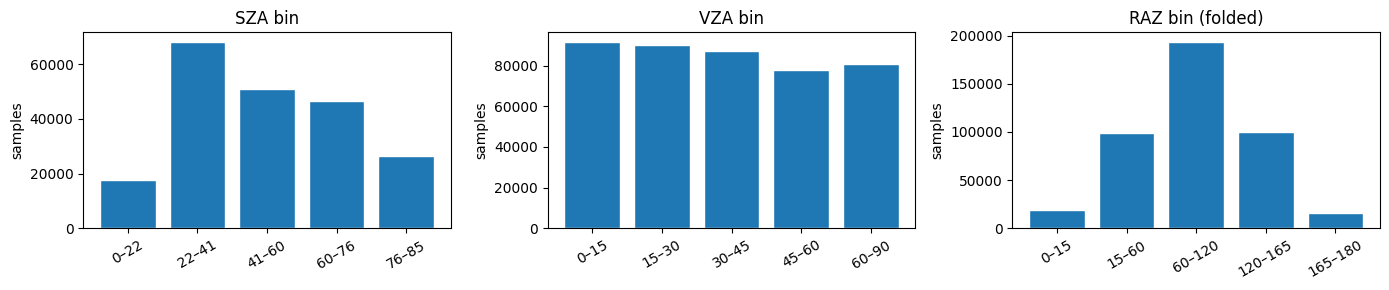

In [12]:
from unfiltered_radiances.unfiltering import _fold_raz, _assign_bin_indices

raz_folded = _fold_raz(raz)
sza_idx, vza_idx, raz_idx = _assign_bin_indices(sza, vza, raz_folded)

print('SZA out-of-range (idx=-1):', (sza_idx == -1).sum())
print('VZA out-of-range (idx=-1):', (vza_idx == -1).sum())
print('RAZ out-of-range (idx=-1):', (raz_idx == -1).sum())

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, (idx, name, edges) in zip(axes, [
    (sza_idx, 'SZA bin', _SZA_EDGES),
    (vza_idx, 'VZA bin', _VZA_EDGES),
    (raz_idx, 'RAZ bin (folded)', _RAZ_EDGES),
]):
    valid = idx[idx >= 0]
    ax.hist(valid, bins=np.arange(-0.5, 5.5), rwidth=0.8, edgecolor='white')
    ax.set_xticks(range(5))
    ax.set_xticklabels([f'{a:.0f}–{b:.0f}' for a, b in zip(edges[:-1], edges[1:])], rotation=30)
    ax.set_title(name)
    ax.set_ylabel('samples')
plt.tight_layout()

In [13]:
# Count samples per (sza_bin, vza_bin, raz_bin)
bin_counts = pd.DataFrame({'sza': sza_idx, 'vza': vza_idx, 'raz': raz_idx})
bin_counts = bin_counts[(bin_counts >= 0).all(axis=1)]
top_bins = bin_counts.value_counts().head(15)
print('Top 15 bins by sample count:')
print(top_bins.to_string())

Top 15 bins by sample count:
sza  vza  raz
1    1    2      6293
     2    2      6263
     0    2      6187
3    0    2      5480
     1    2      5292
1    4    1      5071
3    2    2      4993
1    3    2      4977
3    3    2      4466
1    2    1      4281
     3    1      4127
     4    2      3997
     1    1      3896
3    4    2      3885
2    0    2      3828


---
## 5. One-Bin Regression (Manual)

Pick the most-populated bin and apply the regression by hand to see what's happening.

In [14]:
from sklearn.preprocessing import PolynomialFeatures

# Hardcoded to Clear Ocean, cloud=0 (matching what algorithm.py uses right now)
SCENE = 'Clear Ocean'
CLOUD = 0
scene_idx = SCENE_TYPES.index(SCENE)
cloud_idx  = CLOUD_VALUES.index(CLOUD)

# Pick the most populated valid bin
si, vi, ri = top_bins.index[0]
print(f'Inspecting bin: SZA[{si}]={_SZA_EDGES[si]}–{_SZA_EDGES[si+1]}°, '
      f'VZA[{vi}]={_VZA_EDGES[vi]}–{_VZA_EDGES[vi+1]}°, '
      f'RAZ[{ri}]={_RAZ_EDGES[ri]}–{_RAZ_EDGES[ri+1]}°')

mask = (sza_idx == si) & (vza_idx == vi) & (raz_idx == ri)
print(f'Samples in this bin: {mask.sum():,}')

# Retrieve coefficients
sw_coef  = coef_ds['sw_coefficients'].values[scene_idx, cloud_idx, si, vi, ri]   # (7,)
ssw_coef = coef_ds['ssw_coefficients'].values[scene_idx, cloud_idx, si, vi, ri]
lw_coef  = coef_ds['lw_coefficients'].values[scene_idx, cloud_idx, si, vi, ri]   # (3,)
tot_coef = coef_ds['tot_coefficients'].values[scene_idx, cloud_idx, si, vi, ri]

print(f'\nSW  coefs (intercept + 6 poly terms): {sw_coef}')
print(f'SSW coefs:                             {ssw_coef}')
print(f'LW  coefs (intercept + x + x²):        {lw_coef}')
print(f'TOT coefs:                              {tot_coef}')

coefs_valid = not np.any(np.isnan(sw_coef))
print(f'\nCoefficients populated: {coefs_valid}')

Inspecting bin: SZA[1]=22.2–41.4°, VZA[1]=15.0–30.0°, RAZ[2]=60.0–120.0°
Samples in this bin: 6,293

SW  coefs (intercept + 6 poly terms): [-0.48175588  0.         -3.48358526  2.27055089 -0.93837572  0.47934208
 -0.06162242]
SSW coefs:                             [10.13422029  0.         14.95983755 -3.32871061  4.29806261 -2.19799838
  0.28201154]
LW  coefs (intercept + x + x²):        [1.12674724e+01 1.03900252e+00 5.62759035e-03]
TOT coefs:                              [ 1.70761443e+02 -2.17530066e+00  1.54277729e-02]

Coefficients populated: True


Unfiltered radiances for this bin:
  SW : min=-569947.7529  max=-569771.4199  mean=-569849.5265
  SSW: min=2629612.8110  max=2630421.1778  mean=2629970.7047
  LW : min=65321.2539  max=65321.8555  mean=65321.4023
  TOT: min=29224.3906  max=29330.0957  mean=29289.6055


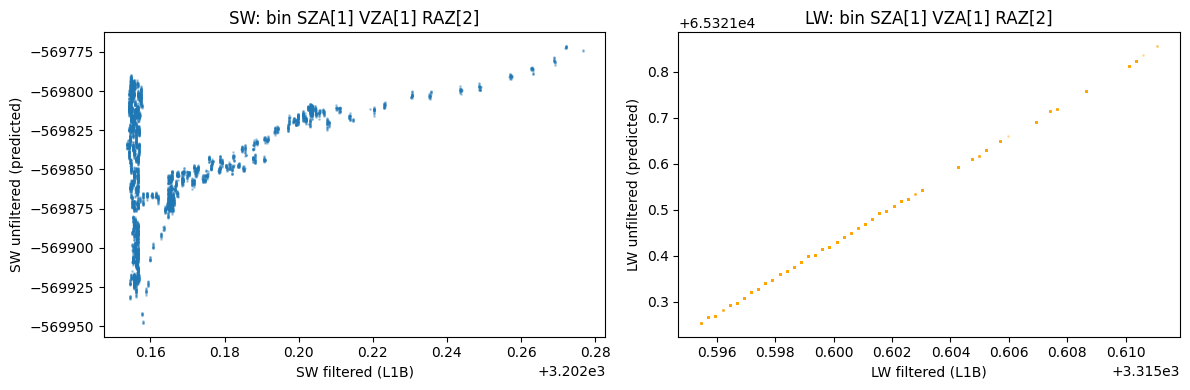

In [15]:
if coefs_valid:
    poly = PolynomialFeatures(degree=2, include_bias=True)
    X = np.vstack([ssw_f[mask], sw_f[mask]]).T       # (n, 2)
    X_poly = poly.fit_transform(X)                    # (n, 6) — bias dropped from coef

    sw_u_bin  = sw_coef[0]  + X_poly @ sw_coef[1:]
    ssw_u_bin = ssw_coef[0] + X_poly @ ssw_coef[1:]
    lw_u_bin  = lw_coef[0]  + lw_coef[1]*lw_f[mask]  + lw_coef[2]*lw_f[mask]**2
    tot_u_bin = tot_coef[0] + tot_coef[1]*tot_f[mask] + tot_coef[2]*tot_f[mask]**2

    print('Unfiltered radiances for this bin:')
    for name, arr in [('SW ', sw_u_bin), ('SSW', ssw_u_bin), ('LW ', lw_u_bin), ('TOT', tot_u_bin)]:
        print(f'  {name}: min={arr.min():.4f}  max={arr.max():.4f}  mean={arr.mean():.4f}')
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(sw_f[mask], sw_u_bin, s=1, alpha=0.3)
    axes[0].set_xlabel('SW filtered (L1B)')
    axes[0].set_ylabel('SW unfiltered (predicted)')
    axes[0].set_title(f'SW: bin SZA[{si}] VZA[{vi}] RAZ[{ri}]')

    axes[1].scatter(lw_f[mask], lw_u_bin, s=1, alpha=0.3, color='orange')
    axes[1].set_xlabel('LW filtered (L1B)')
    axes[1].set_ylabel('LW unfiltered (predicted)')
    axes[1].set_title(f'LW: bin SZA[{si}] VZA[{vi}] RAZ[{ri}]')
    plt.tight_layout()
else:
    print('No coefficients for this bin — trying next...')

---
## 6. Full Unfiltering Pass

In [16]:
from unfiltered_radiances.unfiltering import apply_unfiltering, load_coefficients

coef_ds_fresh = load_coefficients(COEF_FILE)

sw_u, ssw_u, lw_u, tot_u = apply_unfiltering(
    sw_f, ssw_f, lw_f, tot_f, sza, vza, raz,
    coef_ds_fresh,
    scene_idx=scene_idx,
    cloud=CLOUD,
)
coef_ds_fresh.close()

n_total = len(sw_u)
n_filled = int(np.isfinite(sw_u).sum())
print(f'Samples filled: {n_filled:,} / {n_total:,}  ({100*n_filled/n_total:.1f}%)')
print(f'Samples NaN:    {n_total - n_filled:,}  ({100*(n_total-n_filled)/n_total:.1f}%)')
print()
for name, arr in [('SW ', sw_u), ('SSW', ssw_u), ('LW ', lw_u), ('TOT', tot_u)]:
    print(f'{name}: min={np.nanmin(arr):.4f}  max={np.nanmax(arr):.4f}  mean={np.nanmean(arr):.4f}')

Samples filled: 163,521 / 602,200  (27.2%)
Samples NaN:    438,679  (72.8%)

SW : min=-5452912.3622  max=3930403.4574  mean=-87565.9759
SSW: min=-3603268.9618  max=24810716.9455  mean=539226.2565
LW : min=13094.3213  max=131019.4688  mean=67893.1219
TOT: min=-85759.3125  max=192615.1875  mean=9734.0425


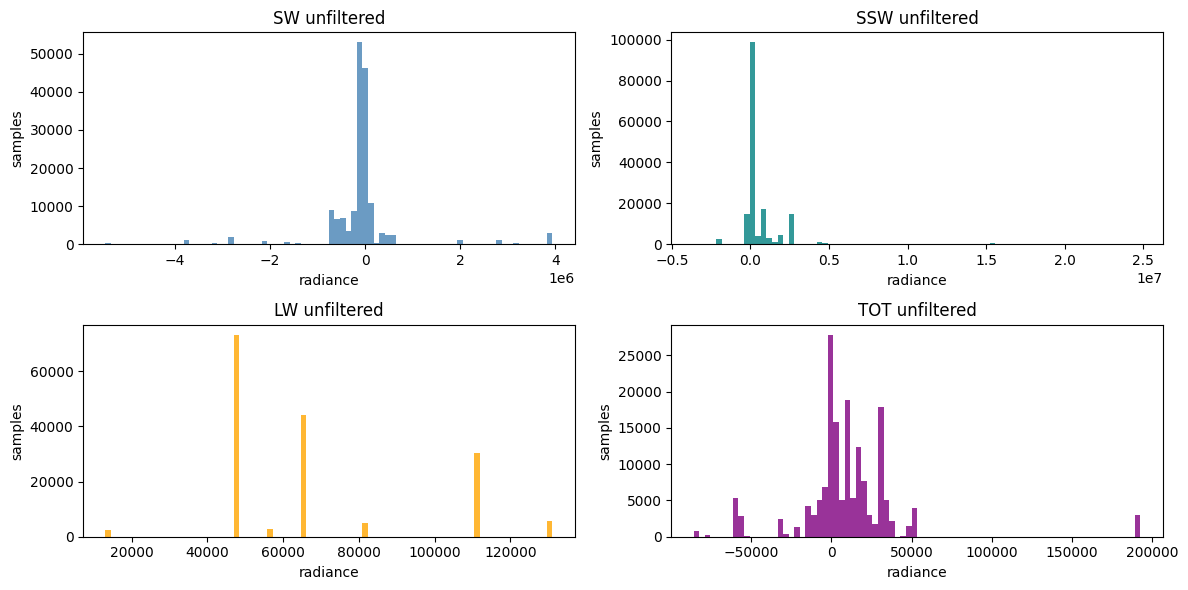

In [17]:
# Distribution of filled outputs
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, (name, arr, color) in zip(axes.flat, [
    ('SW unfiltered',  sw_u,  'steelblue'),
    ('SSW unfiltered', ssw_u, 'teal'),
    ('LW unfiltered',  lw_u,  'orange'),
    ('TOT unfiltered', tot_u, 'purple'),
]):
    valid = arr[np.isfinite(arr)]
    ax.hist(valid, bins=80, color=color, edgecolor='none', alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('radiance')
    ax.set_ylabel('samples')
plt.tight_layout()

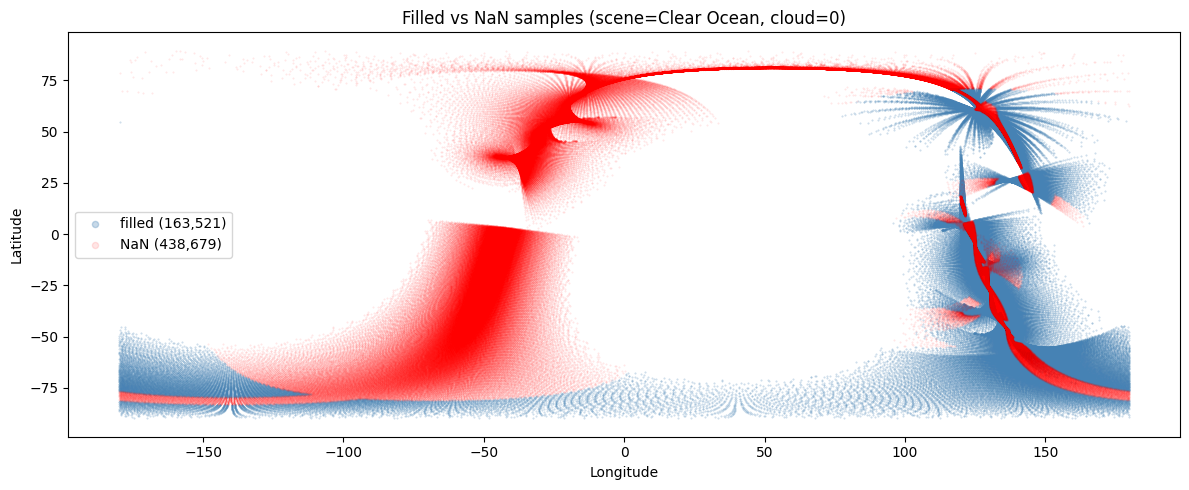

In [18]:
# Where are the NaN samples? Show on a lat/lon map
nan_mask = np.isnan(sw_u)
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(lon[~nan_mask], lat[~nan_mask], s=0.2, alpha=0.3, c='steelblue', label=f'filled ({n_filled:,})')
ax.scatter(lon[nan_mask],  lat[nan_mask],  s=0.2, alpha=0.1, c='red',       label=f'NaN ({n_total-n_filled:,})')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Filled vs NaN samples (scene=Clear Ocean, cloud=0)')
ax.legend(markerscale=10)
plt.tight_layout()

---
## 7. MODTRAN6 Parser Sanity Check

Run `Modtran6NC` on the example file and inspect its `describer_df` — the training-side output.

In [19]:
from tp7.modtran6 import Modtran6NC

m6nc = Modtran6NC(M6_EXAMPLE, srf_path=SRF_DIR)
df = m6nc.describer_df
print(f'Rows: {len(df)}  (expected 9×10×9 = {9*10*9})')
df.head()

Rows: 810  (expected 9×10×9 = 810)


,SZA,VZA,RAZ,Scene,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Total Unfiltered Rads (Integrated),Split Shortwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),Split Shortwave Filtered Rads (Integrated),Total Filtered Rads (Integrated)
0,5.0,5.0,5.0,Clear Ocean,0,0,0.007929,0.008198,0.016127,0.003913,0.005800,0.005302,0.001886,0.014816
1,15.0,5.0,5.0,Clear Ocean,0,1,0.006116,0.008196,0.014311,0.002864,0.004420,0.005300,0.001371,0.013182
2,25.0,5.0,5.0,Clear Ocean,0,2,0.003541,0.008192,0.011734,0.001377,0.002463,0.005298,0.000640,0.010863
3,35.0,5.0,5.0,Clear Ocean,0,3,0.002371,0.008191,0.010561,0.000727,0.001585,0.005297,0.000322,0.009822
4,45.0,5.0,5.0,Clear Ocean,0,4,0.001894,0.008190,0.010084,0.000509,0.001245,0.005297,0.000217,0.009416


In [20]:
df.describe()

,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Total Unfiltered Rads (Integrated),Split Shortwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),Split Shortwave Filtered Rads (Integrated),Total Filtered Rads (Integrated)
count,810.000000,810.000000,810.000000,810.0,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000,810.000000
mean,45.000000,45.000000,90.000000,0.0,404.500000,0.003066,0.007878,0.010944,0.001052,0.002111,0.005104,0.000478,0.010148
std,25.835842,25.835842,55.936239,0.0,233.971152,0.002090,0.000589,0.001906,0.001288,0.001581,0.000382,0.000644,0.001698
min,5.000000,5.000000,5.000000,0.0,0.000000,0.000607,0.006666,0.008470,0.000220,0.000436,0.004330,0.000075,0.007983
25%,25.000000,25.000000,40.000000,0.0,202.250000,0.002002,0.007664,0.010077,0.000486,0.001288,0.004963,0.000209,0.009410
50%,45.000000,45.000000,90.000000,0.0,404.500000,0.002635,0.008023,0.010719,0.000729,0.001742,0.005190,0.000316,0.009901
75%,65.000000,65.000000,140.000000,0.0,606.750000,0.003604,0.008166,0.011313,0.001142,0.002446,0.005281,0.000507,0.010376
max,85.000000,85.000000,175.000000,0.0,809.000000,0.024414,0.008888,0.031116,0.016672,0.018827,0.005785,0.008426,0.028601


### MODTRAN 3.7 (Tape7) describer_df

Load a Tape7 file for the same scene type (Clear Ocean) so both dataframes can be compared directly.

In [22]:
from tp7.tp7 import Tape7
import glob

# Pick clear ocean files across all four SZA folders for good coverage
tp7_clear_ocean = sorted(glob.glob(str(REPO / 'data/Modtran_3-7_data/**/oceclr_*.tp7'), recursive=True))
print(f'Clear ocean .tp7 files ({len(tp7_clear_ocean)}):')
for f in tp7_clear_ocean:
    print(' ', Path(f).name)

Clear ocean .tp7 files (5):
  oceclr_sz00L.tp7
  oceclr_sz41L.tp7
  oceclr_sz60L.tp7
  oceclr_sz75L.tp7
  oceclr_sz85L.tp7


In [23]:
# Load all clear ocean Tape7 files and concatenate — mirrors how load_dataset() works
frames_37 = []
for f in tp7_clear_ocean:
    t7 = Tape7(f)
    frames_37.append(t7.describer_df)
df_37 = pd.concat(frames_37, ignore_index=True)

print(f'MODTRAN 3.7 rows: {len(df_37)}  (across {len(tp7_clear_ocean)} files)')
df_37.head()

MODTRAN 3.7 rows: 735  (across 5 files)


,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Total Unfiltered Rads (Integrated),Split Shortwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),Split Shortwave Filtered Rads (Integrated),Total Filtered Rads (Integrated)
0,Clear Ocean,0.0,0.0,0.0,0,0,61.754012,104.742202,166.496214,26.271219,44.054995,66.329029,12.216651,153.899323
1,Clear Ocean,0.0,0.0,0.0,0,1,59.861764,100.234847,160.096611,25.454931,42.589899,63.754290,11.880196,147.781879
2,Clear Ocean,0.0,0.0,0.0,0,2,58.575515,96.211097,154.786612,24.731224,41.593573,61.425873,11.545634,142.700407
3,Clear Ocean,0.0,0.0,0.0,0,3,56.280375,94.357094,150.637468,23.425207,39.814353,60.343060,10.938403,138.798035
4,Clear Ocean,0.0,0.0,0.0,0,4,52.776801,92.622868,145.399669,21.307070,37.074413,59.324170,9.941104,133.883147


In [24]:
df_37.describe()

,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Total Unfiltered Rads (Integrated),Split Shortwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),Split Shortwave Filtered Rads (Integrated),Total Filtered Rads (Integrated)
count,735.000000,735.000000,735.000000,735.0,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000
mean,52.685429,53.558810,85.714286,0.0,73.000000,34.799009,86.556485,121.355494,11.878132,24.141397,55.436233,5.269596,112.684894
std,29.260236,24.741845,63.369295,0.0,42.463159,33.027888,10.659982,27.124660,20.619313,24.998672,6.545968,10.011722,24.095635
min,0.000000,0.000000,0.000000,0.0,0.000000,3.547238,68.702548,95.254049,0.488983,2.341881,44.419071,0.166521,88.968967
25%,41.387000,30.000000,37.500000,0.0,36.000000,14.871381,85.880108,108.484338,2.240101,9.437760,55.131164,0.892238,102.077607
50%,59.975000,45.000000,90.000000,0.0,73.000000,24.252702,89.326754,114.638623,5.428301,15.410539,57.167934,2.286543,106.359174
75%,74.946000,60.000000,142.500000,0.0,110.000000,46.558785,93.125803,125.940289,13.806539,32.294618,59.567513,5.821730,115.452085
max,85.850000,89.947000,172.500000,0.0,146.000000,243.482259,104.742310,312.184807,164.321841,185.209599,66.329091,84.011792,285.103972


In [25]:
# Side-by-side summary: key radiance column stats for M6 vs M3.7 (both Clear Ocean)
rad_cols = [
    'Shortwave Filtered Rads (Integrated)',
    'Longwave Filtered Rads (Integrated)',
    'Split Shortwave Filtered Rads (Integrated)',
    'Total Filtered Rads (Integrated)',
    'Shortwave Unfiltered Rads (Integrated)',
    'Longwave Unfiltered Rads (Integrated)',
]

short = {
    'Shortwave Filtered Rads (Integrated)':       'SW Filtered',
    'Longwave Filtered Rads (Integrated)':        'LW Filtered',
    'Split Shortwave Filtered Rads (Integrated)': 'SSW Filtered',
    'Total Filtered Rads (Integrated)':           'TOT Filtered',
    'Shortwave Unfiltered Rads (Integrated)':     'SW Unfiltered',
    'Longwave Unfiltered Rads (Integrated)':      'LW Unfiltered',
}

rows = []
for col in rad_cols:
    for label, dframe in [('MODTRAN 6', df), ('MODTRAN 3.7', df_37)]:
        rows.append({
            'channel': short[col],
            'source':  label,
            'min':     dframe[col].min(),
            'max':     dframe[col].max(),
            'mean':    dframe[col].mean(),
            'std':     dframe[col].std(),
        })

compare = pd.DataFrame(rows).set_index(['channel', 'source'])
compare.round(6)

min         max        mean        std
channel       source                                                   
SW Filtered   MODTRAN 6     0.000436    0.018827    0.002111   0.001581
              MODTRAN 3.7   2.341881  185.209599   24.141397  24.998672
LW Filtered   MODTRAN 6     0.004330    0.005785    0.005104   0.000382
              MODTRAN 3.7  44.419071   66.329091   55.436233   6.545968
SSW Filtered  MODTRAN 6     0.000075    0.008426    0.000478   0.000644
              MODTRAN 3.7   0.166521   84.011792    5.269596  10.011722
TOT Filtered  MODTRAN 6     0.007983    0.028601    0.010148   0.001698
              MODTRAN 3.7  88.968967  285.103972  112.684894  24.095635
SW Unfiltered MODTRAN 6     0.000607    0.024414    0.003066   0.002090
              MODTRAN 3.7   3.547238  243.482259   34.799009  33.027888
LW Unfiltered MODTRAN 6     0.006666    0.008888    0.007878   0.000589
              MODTRAN 3.7  68.702548  104.742310   86.556485  10.659982

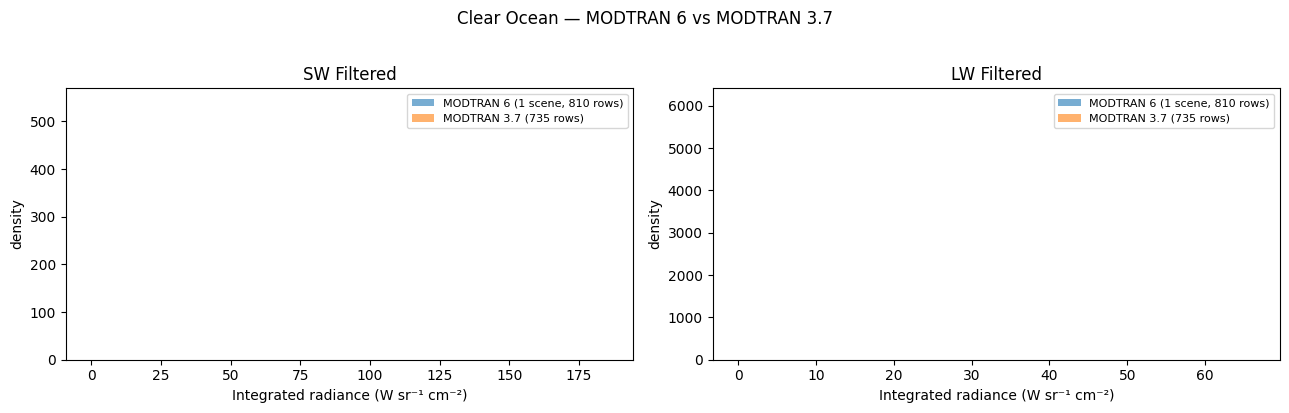

In [26]:
# Visual comparison: filtered SW and LW distributions, M6 vs M3.7
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in [
    (axes[0], 'Shortwave Filtered Rads (Integrated)', 'SW Filtered'),
    (axes[1], 'Longwave Filtered Rads (Integrated)',  'LW Filtered'),
]:
    ax.hist(df[col],    bins=40, alpha=0.6, label='MODTRAN 6 (1 scene, 810 rows)',   density=True)
    ax.hist(df_37[col], bins=40, alpha=0.6, label=f'MODTRAN 3.7 ({len(df_37)} rows)', density=True)
    ax.set_title(title)
    ax.set_xlabel('Integrated radiance (W sr⁻¹ cm⁻²)')
    ax.set_ylabel('density')
    ax.legend(fontsize=8)

plt.suptitle('Clear Ocean — MODTRAN 6 vs MODTRAN 3.7', y=1.02)
plt.tight_layout()

In [27]:
# Compare Modtran6NC integrated values to the pre-integrated values already in the file
m6_check = xr.open_dataset(M6_EXAMPLE)
preint_sw = m6_check['MODTRAN6_SW_RAD_TOA_CERES_TRMM'].values.reshape(-1)  # W/(sr·cm²)
preint_lw = m6_check['MODTRAN6_LW_RAD_TOA_CERES_TRMM'].values.reshape(-1)
m6_check.close()

our_sw = df['Shortwave Filtered Rads (Integrated)'].values  # our integration, W/(sr·cm²) after nm integration
our_lw = df['Longwave Filtered Rads (Integrated)'].values

print('Pre-integrated SW (from file, W/(sr·cm²)): [{:.4e}, {:.4e}]'.format(preint_sw.min(), preint_sw.max()))
print('Our integrated SW (Modtran6NC):             [{:.4e}, {:.4e}]'.format(our_sw.min(), our_sw.max()))
print()
print('Pre-integrated LW: [{:.4e}, {:.4e}]'.format(preint_lw.min(), preint_lw.max()))
print('Our integrated LW: [{:.4e}, {:.4e}]'.format(our_lw.min(), our_lw.max()))
print()
print('Note: our integration is over a different SRF bandpass than the ERBE/CERES values in the file.')

Pre-integrated SW (from file, W/(sr·cm²)): [6.0835e-04, 2.4434e-02]
Our integrated SW (Modtran6NC):             [4.3577e-04, 1.8827e-02]

Pre-integrated LW: [6.6960e-03, 8.9365e-03]
Our integrated LW: [4.3300e-03, 5.7851e-03]

Note: our integration is over a different SRF bandpass than the ERBE/CERES values in the file.


---
## 8. Unit Mismatch Summary

Cells above reveal:

| Quantity | Source | Units | Typical SW value |
|---|---|---|---|
| `Filtered_Radiance_SW` | L1B | `W/(m²·sr·nm)` ¹ | ~3200 |
| `MODTRAN6_SW_RAD_TOA_CERES_TRMM` | M6 pre-integrated | `W/(sr·cm²)` | 6e-4 – 0.024 |
| `MODTRAN6_SW_RAD_TOA_CERES_TRMM` × 1e4 | converted | `W/(sr·m²)` | 6 – 240 |
| Modtran6NC filtered (our integration) | M6 → simpson | `W/(sr·cm²)` ² | TBD |

¹ Units label in L1B is likely wrong — a SRF-filtered broadband should be `W/(m²·sr)`, not `/nm`.  
² Our integration is in nm, producing W/(sr·cm²) because spectral values are W/(sr·cm²·nm).

**To fix:** either convert L1B inputs before regression, or regenerate coefficients from M6 data
with values in the same scale as the L1B. The coefficients from MODTRAN 3.7 (Tape7) were
also integrated over µm from a different unit origin — those should be considered deprecated
once M6 coefficients are available.

In [28]:
# Cleanup
l1b.close()
coef_ds.close()